# QV Plots 

- Figure 1
- Suppl Figure
- Suppl Table

In [25]:
suppressPackageStartupMessages(library(tidyverse))
suppressMessages(source("../scripts/00_R_presets.R"))

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


In [26]:
# Read QV data
dt <- read_tsv("../../doc/tables/for_plots/all_merqury_qv.tsv", show_col_types = FALSE) %>%
  mutate(modifier = ifelse(is.na(modifier), "", modifier)) %>%
  mutate(k = as.factor(k))
head(dt)

sample,modifier,k,tech,haplotype,unique_kmers,total_kmers,qv,error_rate
<chr>,<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
T2T00,,21,NSXPlus,hap1,219743,2926192796,54.4659,3.57609e-06
T2T00,,21,NSXPlus,hap2,399797,3037390447,52.0285,6.26826e-06
T2T00,,21,NSXPlus,diploid,619540,5963583243,53.0564,4.94725e-06
T2T00,,31,NSXPlus,hap1,605786,2926192066,51.7530,6.67880e-06
T2T00,,31,NSXPlus,hap2,660564,3037389287,51.5390,7.01614e-06
T2T00,,31,NSXPlus,diploid,1266350,5963581353,51.6427,6.85061e-06


In [27]:
# summary stats
dt %>%
  group_by(k, modifier) %>%
  summarise(median_qv = median(qv), mean_qv = mean(qv), n = n(), min_qv = min(qv), max_qv = max(qv))

`summarise()` has grouped output by 'k'. You can override using the `.groups`
argument.


k,modifier,median_qv,mean_qv,n,min_qv,max_qv
<fct>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
21,,60.13720,60.11753,60,52.0285,65.3384
21,apk_polished,48.78610,48.45280,3,47.4750,49.0973
21,trio,54.54355,54.54355,2,52.8306,56.2565
31,,51.24705,50.88784,60,47.7560,53.1906
31,apk_polished,47.74720,47.80360,3,46.2235,49.4401
31,trio,50.09840,50.09840,2,48.8033,51.3935
37,,48.27190,47.98015,60,45.5291,49.8362
37,apk_polished,46.82130,47.12877,3,45.7090,48.8560
37,trio,47.48830,47.48830,2,46.3895,48.5871


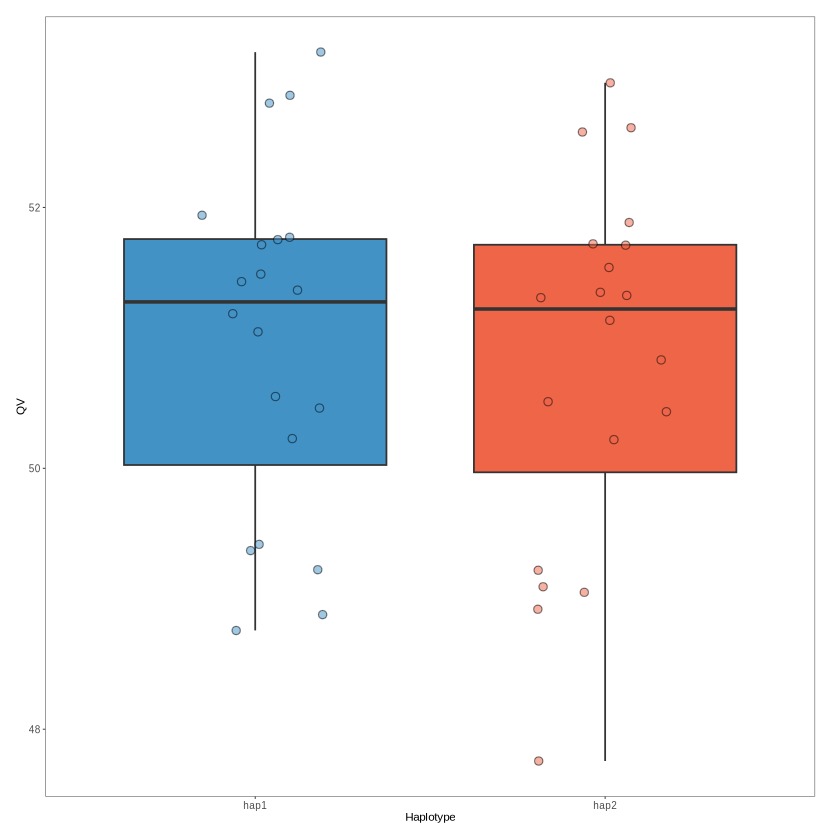

In [28]:
# Plot QV summary

fig1_qv <- dt %>%
  filter (modifier == "") %>%
  filter (haplotype != "diploid") %>%
  filter(k == 31) %>%
  ggplot(aes(x = haplotype, fill = haplotype, y = qv)) +
  geom_boxplot(color = "grey20") +
  geom_jitter(width = 0.2, size = 2, shape=21, alpha = 0.5) +
  scale_fill_manual(values = col_haplotype) +
  labs(y = "QV", x = "Haplotype") +
  theme(legend.position = "none")

fig1_qv
ggsave("../../doc/figures/fig1_qv.pdf", fig1_qv, width = 2, height = 2.5)
ggsave("../../doc/figures/fig1_qv.png", fig1_qv, width = 2, height = 2.5)


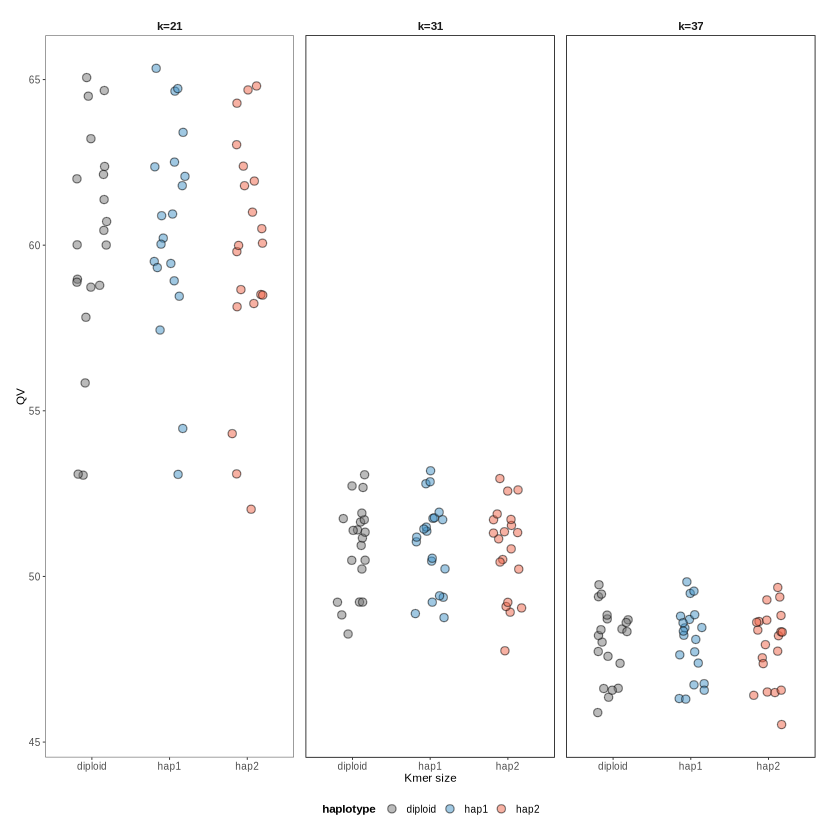

In [35]:
# Plot QV different kmers

fig1_qv_k <- dt %>%
  filter (modifier == "") %>%
  ggplot(aes(x = haplotype, fill = haplotype, y = qv)) +
  facet_wrap(~k) +
  geom_jitter(width = 0.2, size = 2, shape=21, alpha = 0.5) +
  scale_fill_manual(values = col_haplotype) +
  labs(y = "QV", x = "Haplotype") +
  theme(legend.position = "bottom")
  fig1_qv_k <- fig1_qv_k + facet_wrap(~k, labeller = labeller(k = function(x) paste0("k=", x)))
fig1_qv_k
ggsave("../../doc/figures/fig1_qv_k.pdf", fig1_qv_k, width = 4, height = 3)
ggsave("../../doc/figures/fig1_qv_k.png", fig1_qv_k, width = 4, height = 3)

Warning message in geom_point(width = 0.2, size = 2, shape = 21, alpha = 0.5):
“Ignoring unknown parameters: `width`”


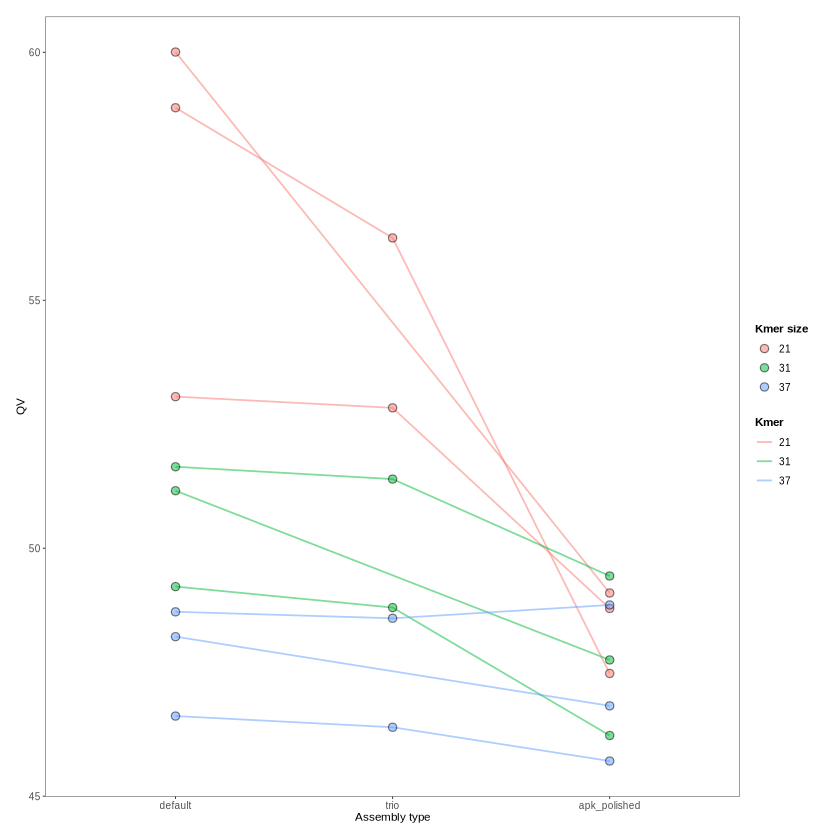

In [51]:
# Modifier Plot

fig1_qv_mod <- dt %>%
    mutate(modifier = factor(modifier,
        levels = c("", "trio", "apk_polished"),
        labels = c("default", "trio", "apk_polished"))) %>%
    filter(sample %in% c("T2T00", "T2T04", "T2T03")) %>%
    filter(haplotype == "diploid") %>%
    ggplot(aes(x = modifier, fill = k, y = qv)) +
    geom_line(aes(group = interaction(sample, k, haplotype), color = k), alpha = 0.5) +
    geom_point(width = 0.2, size = 2, shape = 21, alpha = 0.5) +
    labs(y = "QV", x = "Assembly type", fill = "Kmer size", colour = "Kmer")

fig1_qv_mod
ggsave("../../doc/figures/fig1_qv_mod.pdf", fig1_qv_mod, width = 3, height = 2.5)
ggsave("../../doc/figures/fig1_qv_mod.png", fig1_qv_mod, width = 3, height = 2.5)



Warning message in geom_point(width = 0.2, size = 2, shape = 21, alpha = 0.5):
“Ignoring unknown parameters: `width`”


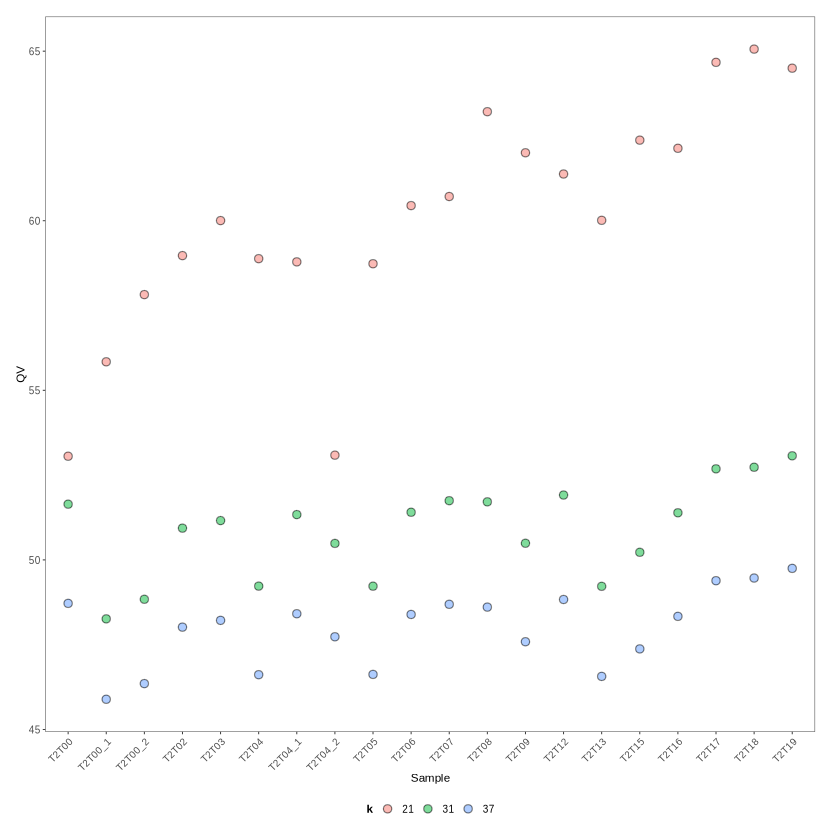

In [56]:
# Plot QC per sample
fig1_qv_sample <- dt %>%
  filter(modifier == "") %>%
  filter(haplotype == "diploid") %>%
  #filter(k == 31) %>%
  ggplot(aes(x = sample, fill = k, y = qv)) +
  geom_point(width = 0.2, size = 2, shape=21, alpha = 0.5) +
  labs(y = "QV", x = "Sample") +
  theme(legend.position = "bottom", axis.text.x = element_text(angle = 45, hjust = 1))

fig1_qv_sample
ggsave("../../doc/figures/fig1_qv_sample.png", fig1_qv_sample, width = 4, height = 2.5)
ggsave("../../doc/figures/fig1_qv_sample.pdf", fig1_qv_sample, width = 4, height = 2.5)
